# Using Natural Language Processing (NLP) to analyse customer reviews and uncover systemic pain points within a UK restaurant chain.

Due to confidentiality constraints, the original dataset has been replaced with a synthetic dataset

In [1]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 15.6 MB/s eta 0:00:00


In [2]:
!pip install wordcloud

In [3]:
!pip install openpyxl

In [4]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 60.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=fe5664ce60b111a45cb0c9f84c7ffd2a3a5f5ae6afbde3d7cac4f4d9cc5c85de
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [5]:
import numpy as np
import pandas as pd
import collections
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import warnings
import plotly.express as px
import time
import pickle

from nltk.corpus import stopwords
from nltk import word_tokenize
from bertopic import BERTopic
from wordcloud import WordCloud
from transformers import AutoTokenizer, pipeline, AutoModelForCausalLM
from datasets import Dataset
from geopy.geocoders import Nominatim

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [8]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
google = pd.read_csv('/content/drive/MyDrive/Data Science/Git Hub Project Portfolio/NLP Synthetic Data/FastFood_google.csv')
trustpilot = pd.read_csv('/content/drive/MyDrive/Data Science/Git Hub Project Portfolio/NLP Synthetic Data/FastFood_trustpilot.csv')

In [10]:
google.sample(3)

,Review Text,Review Stars,Restaurant Place,Creationdate
919,"Food was okay, but the place was quite dirty.",4,Liverpool City Centre,2023-02-01 02:53:37.218490
6920,"Amazing experience, highly recommend.",5,Liverpool Anfield,2023-12-16 02:53:37.218490
18466,"Poor quality ingredients, not worth the money.",1,Bristol Clifton,2024-06-12 02:53:37.218490


In [11]:
trustpilot.sample(3)

,Review Text,Review Stars,Location,DateTime
7977,Delicious meals and very clean environment.,4,London Chelsea,2024-06-15 02:24:00.048415
9560,Rude staff and long waiting times.,2,Glasgow City Centre,2024-07-15 02:24:00.048415
8875,"Amazing experience, highly recommend.",5,London Soho,2024-07-02 02:24:00.048415


In [12]:
# Remove reviews with missing review content
google = google.dropna(subset='Review Text')
trustpilot = trustpilot.dropna(subset='Review Text')

google = google[google['Review Text'].str.strip() != '']
trustpilot = trustpilot[trustpilot['Review Text'].str.strip() != '']

In [13]:
# Remove non-english reviews
from langdetect import detect, DetectorFactory

def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'

In [14]:
google['Review Language'] = google['Review Text'].apply(detect_language)
trustpilot['Review Language'] = trustpilot['Review Text'].apply(detect_language)

# Filter Google reviews for English only
google = google[google['Review Language'] == 'en']

# Filter Trustpilot reviews for English only
trustpilot = trustpilot[trustpilot['Review Language'] == 'en']

# Initial data investigation

In [15]:
# Identify unique locations
google_n_unique_locations = google['Restaurant Place'].nunique()
print(f"Number of unique locations in Google dataset: {google_n_unique_locations}")

trustpilot_n_unique_locations = trustpilot['Location'].nunique()
print(f"Number of unique locations in Trustpilot dataset: {trustpilot_n_unique_locations}")

Number of unique locations in Google dataset: 25
Number of unique locations in Trustpilot dataset: 25


In [16]:
# Find common locations
google_location_set = set(google['Restaurant Place'].unique())
trustpilot_location_set = set(trustpilot['Location'].unique())

common_locations = google_location_set & trustpilot_location_set

print(f"There are {len(common_locations)} common locations")

There are 25 common locations


In [17]:
common_locations

{'Birmingham City Centre',
 'Birmingham Edgbaston',
 'Birmingham Solihull',
 'Bristol City Centre',
 'Bristol Clifton',
 'Cardiff Bay',
 'Cardiff City Centre',
 'Edinburgh New Town',
 'Edinburgh Old Town',
 'Glasgow City Centre',
 'Glasgow West End',
 'Leeds City Centre',
 'Leeds Headingley',
 'Liverpool Anfield',
 'Liverpool City Centre',
 'London Camden',
 'London Canary Wharf',
 'London Chelsea',
 'London Hackney',
 'London Soho',
 'Manchester Central',
 'Manchester Didsbury',
 'Manchester Salford',
 'Sheffield City Centre',
 'Sheffield Ecclesall Road'}

In [18]:
# Create a function to carry out preprocessing -  change to lower case, remove stopwords , and remove non-alphabetic characters.

def preprocess(review_list):

  cleaned_tokens = [] # This will hold all individual cleaned tokens from all reviews
  cleaned_review_all = [] # This will hold each cleaned review as a single string

  for review in review_list:
    review_text = str(review) # Ensure review is a string

    # Change to lower case
    review_text = review_text.lower()

    # Remove numbers and other non-alphabetic characters.
    review_text = re.sub('[^a-z]+', ' ', review_text).strip()

    # Tokenise
    word_tokens = word_tokenize(review_text)

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    # Include 'Pure' 'Gym' 'PureGym'
    stop_words.update(['pure', 'gym', 'puregym'])

    # Filter out stop words and single-character words from the current review's tokens
    current_review_filtered_words = [w for w in word_tokens if w not in stop_words and len(w) > 1]

    # Add these filtered words to the overall list of all cleaned tokens
    cleaned_tokens.extend(current_review_filtered_words)

    # Join the filtered words for the current review to form a single cleaned string for this review
    cleaned_review_string = ' '.join(current_review_filtered_words)
    cleaned_review_all.append(cleaned_review_string)

  return cleaned_tokens, cleaned_review_all

Plot word frequency

In [19]:
# Create a function to plot word frequency

def plot_word_frequency(reviews, title, top_n = 10):
  FreqDist = nltk.FreqDist(reviews)
  FreqDist_df = pd.DataFrame(FreqDist.most_common(top_n), columns=['Word', 'Frequency'])

  plt.figure(figsize=(10,10))
  plt.title(title)
  sns.set_style("whitegrid")
  ax = sns.barplot(x="Word",y="Frequency", data=FreqDist_df)
  plt.show()

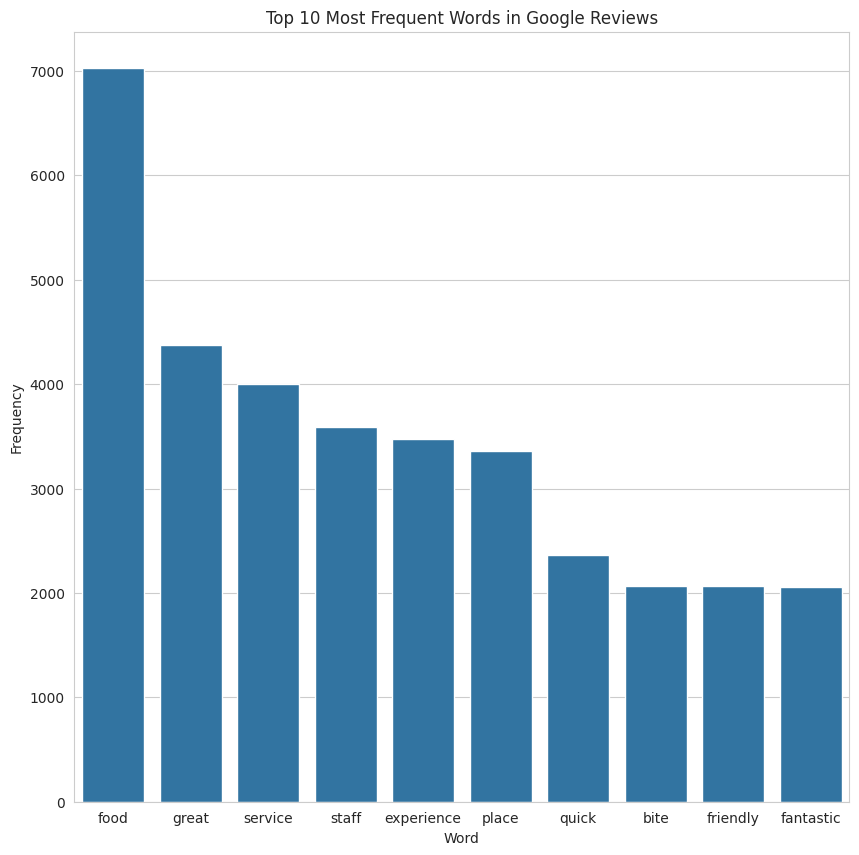

In [21]:
# Plot for Google reviews
google_reviews = google['Review Text'].to_list()
cleaned_google_tokens, cleaned_google_reviews = preprocess(google_reviews)

plot_word_frequency(cleaned_google_tokens,'Top 10 Most Frequent Words in Google Reviews', 10)

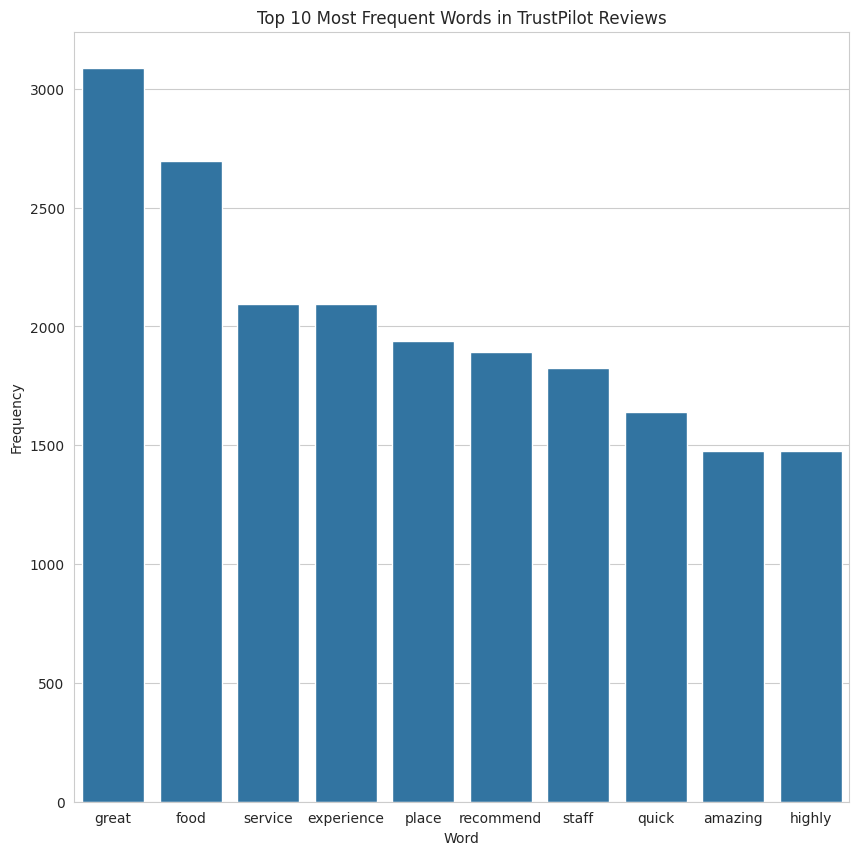

In [22]:
# Plot for trustpilot reviews
trustpilot_reviews = trustpilot['Review Text'].to_list()
cleaned_trustpilot_tokens, cleaned_trustpilot_reviews = preprocess(trustpilot_reviews)

plot_word_frequency(cleaned_trustpilot_tokens,'Top 10 Most Frequent Words in TrustPilot Reviews', 10)

Create word clouds

In [23]:
# Reusable function to present word cloud
def present_word_cloud(reviews):
  plt.figure(figsize = (100,100))
  wc = WordCloud(background_color = 'black', max_words = 1000,  max_font_size = 50)
  wc.generate(' '.join(reviews))
  plt.imshow(wc)
  plt.axis('off')

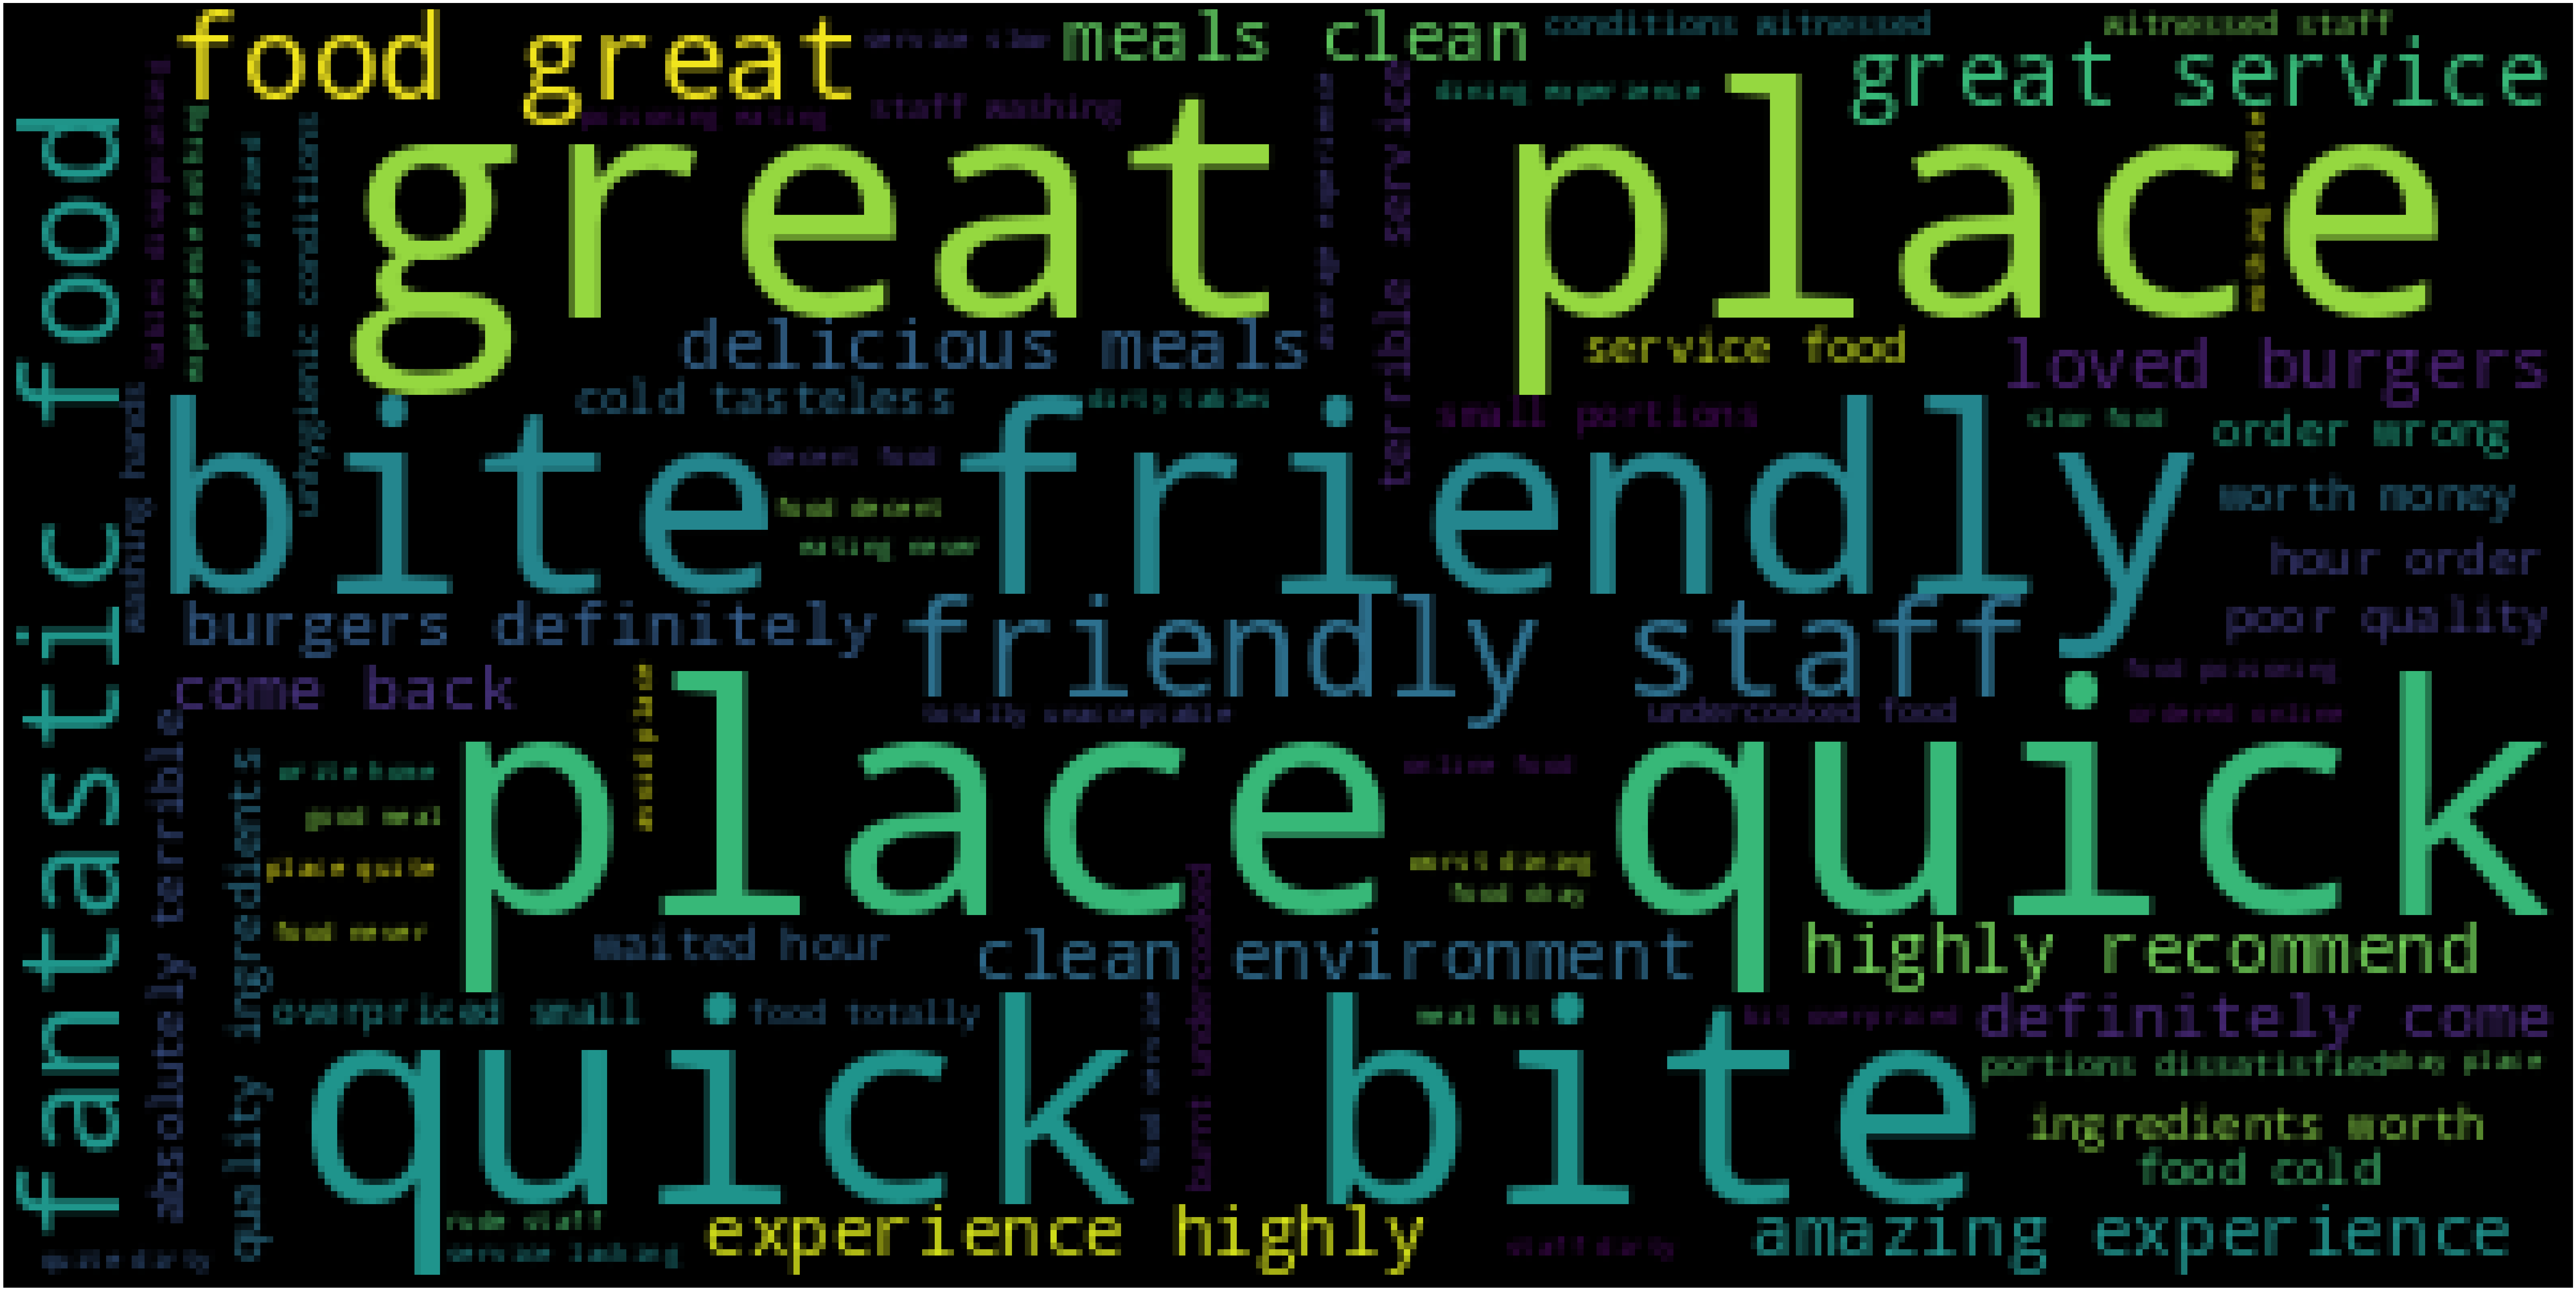

In [24]:
present_word_cloud(cleaned_google_tokens)

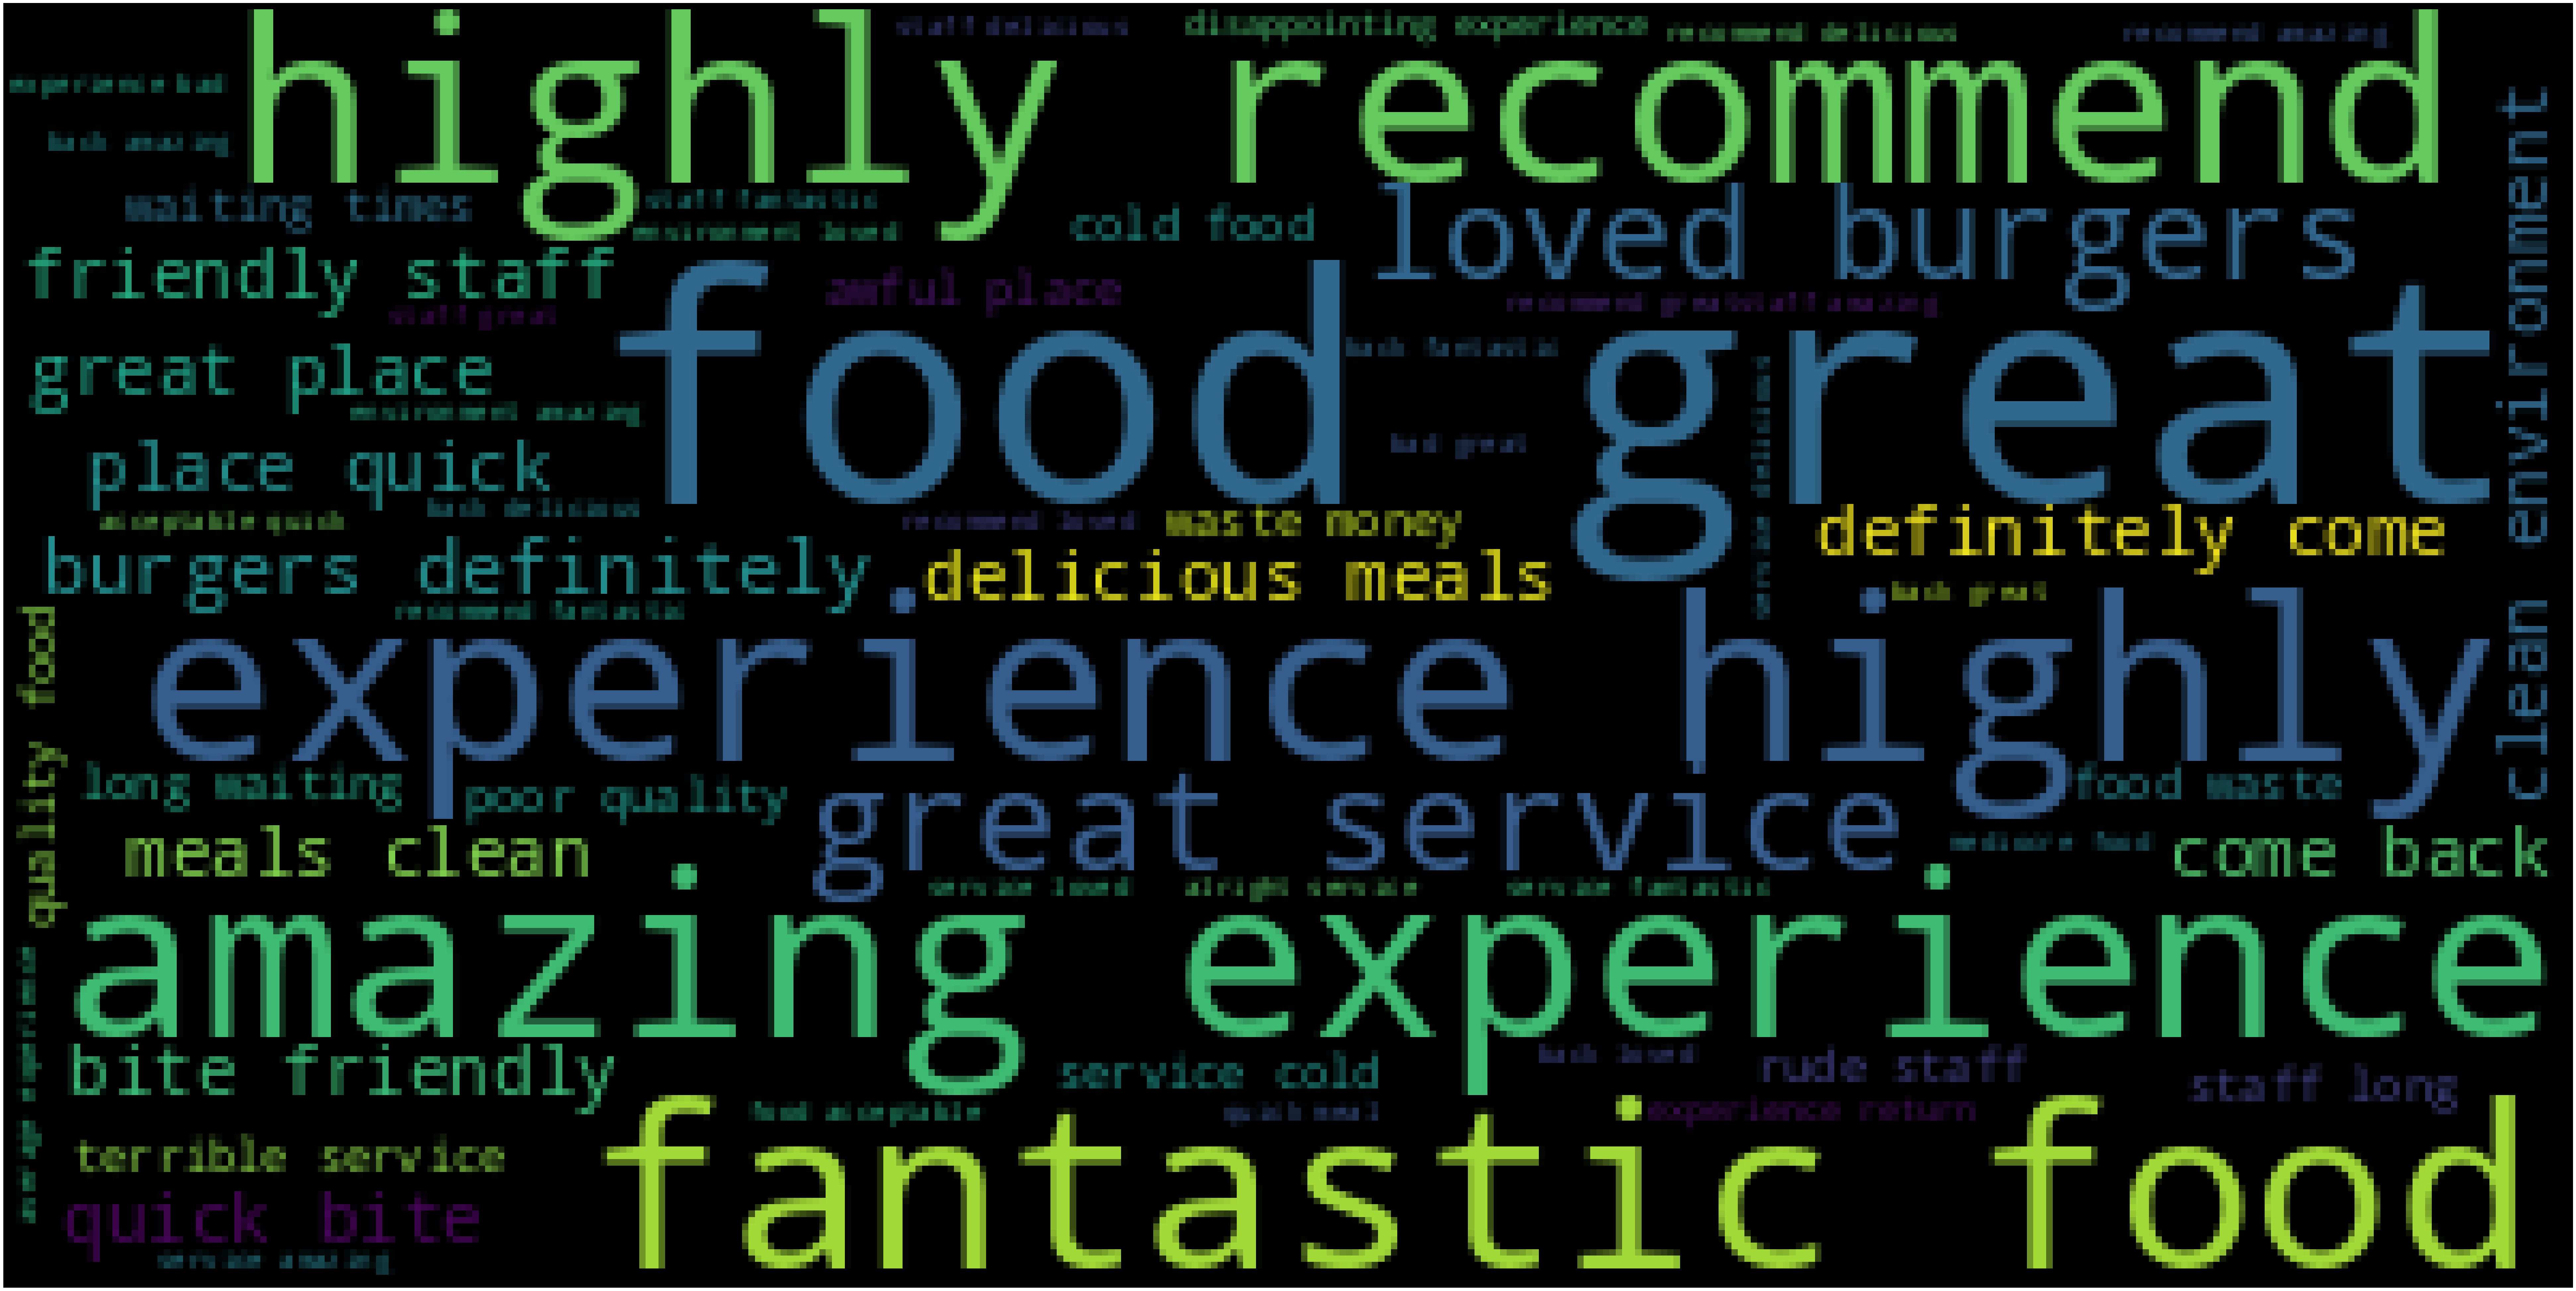

In [25]:
present_word_cloud(cleaned_trustpilot_tokens)

Identify negative reviews and repeat word distrbution and word clouds

In [26]:
# Google
df_neg_google_reviews = google.loc[google['Review Stars'] < 3]
cleaned_neg_google_tokens, cleaned_neg_google_reviews = preprocess(df_neg_google_reviews['Review Text'].to_list())

# trustpilot
df_neg_trustpilot_reviews = trustpilot.loc[trustpilot['Review Stars'] < 3]
cleaned_neg_trustpilot_tokens, cleaned_neg_trustpilot_reviews  = preprocess(df_neg_trustpilot_reviews['Review Text'].to_list())

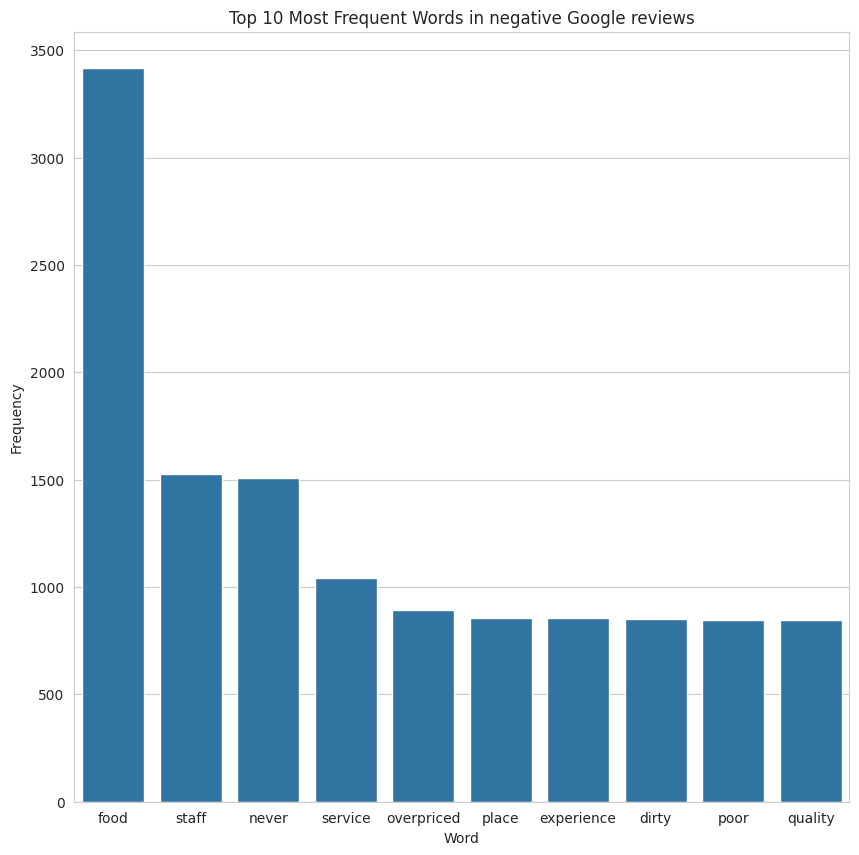

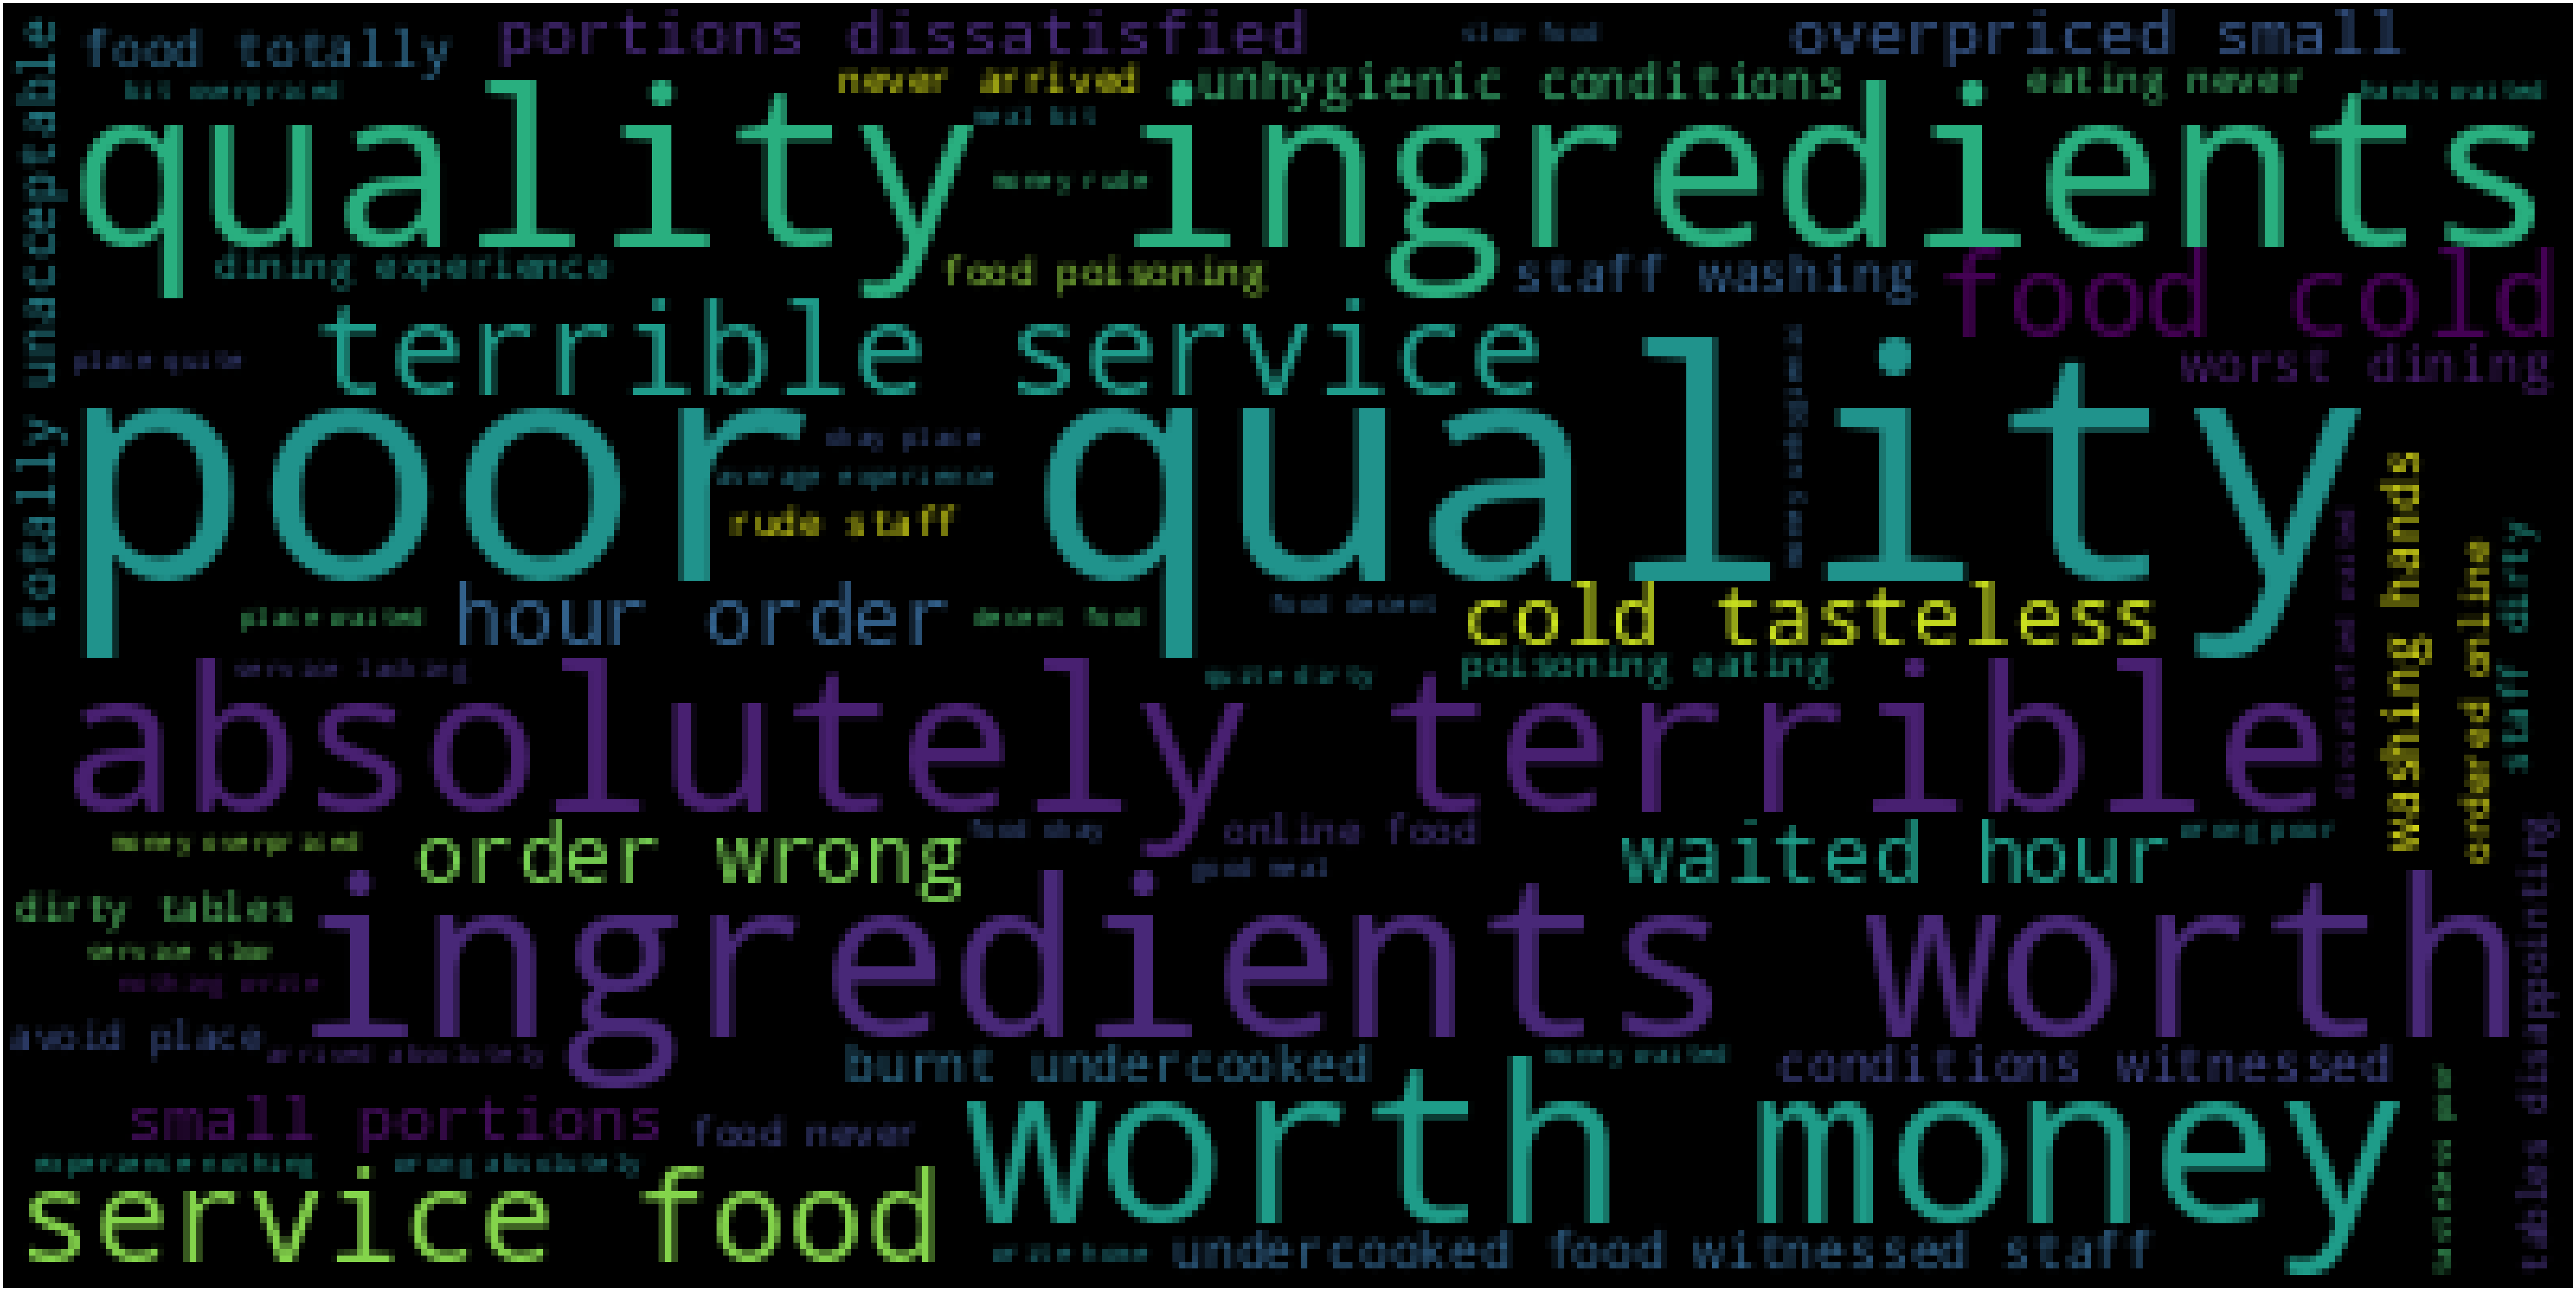

In [27]:
plot_word_frequency(cleaned_neg_google_tokens, 'Top 10 Most Frequent Words in negative Google reviews', 10)
present_word_cloud(cleaned_neg_google_tokens)

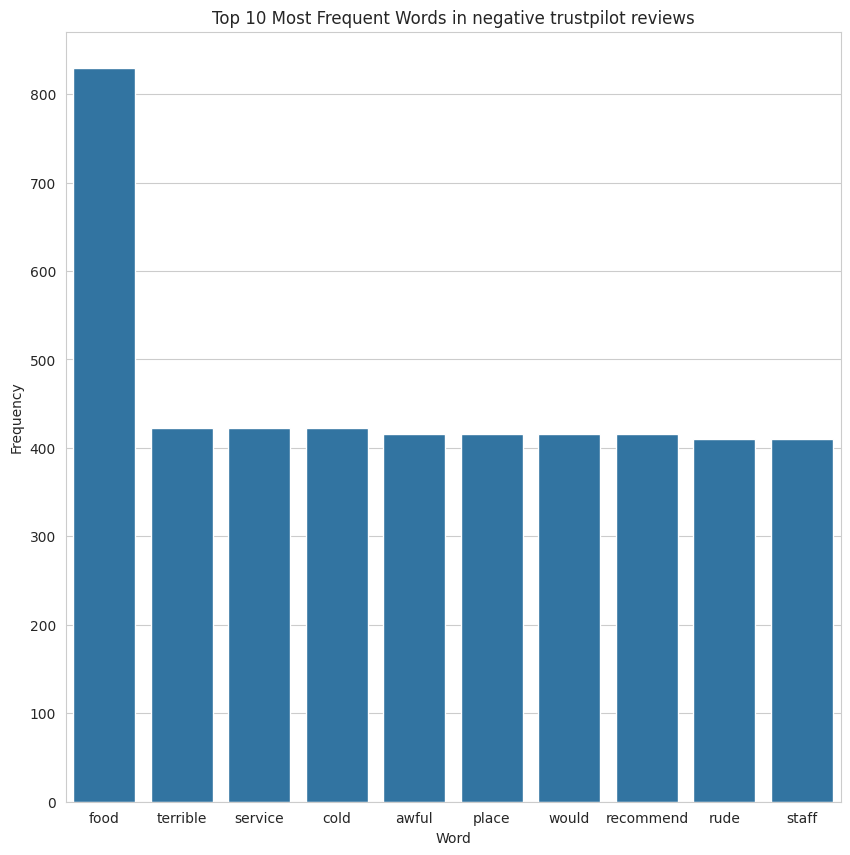

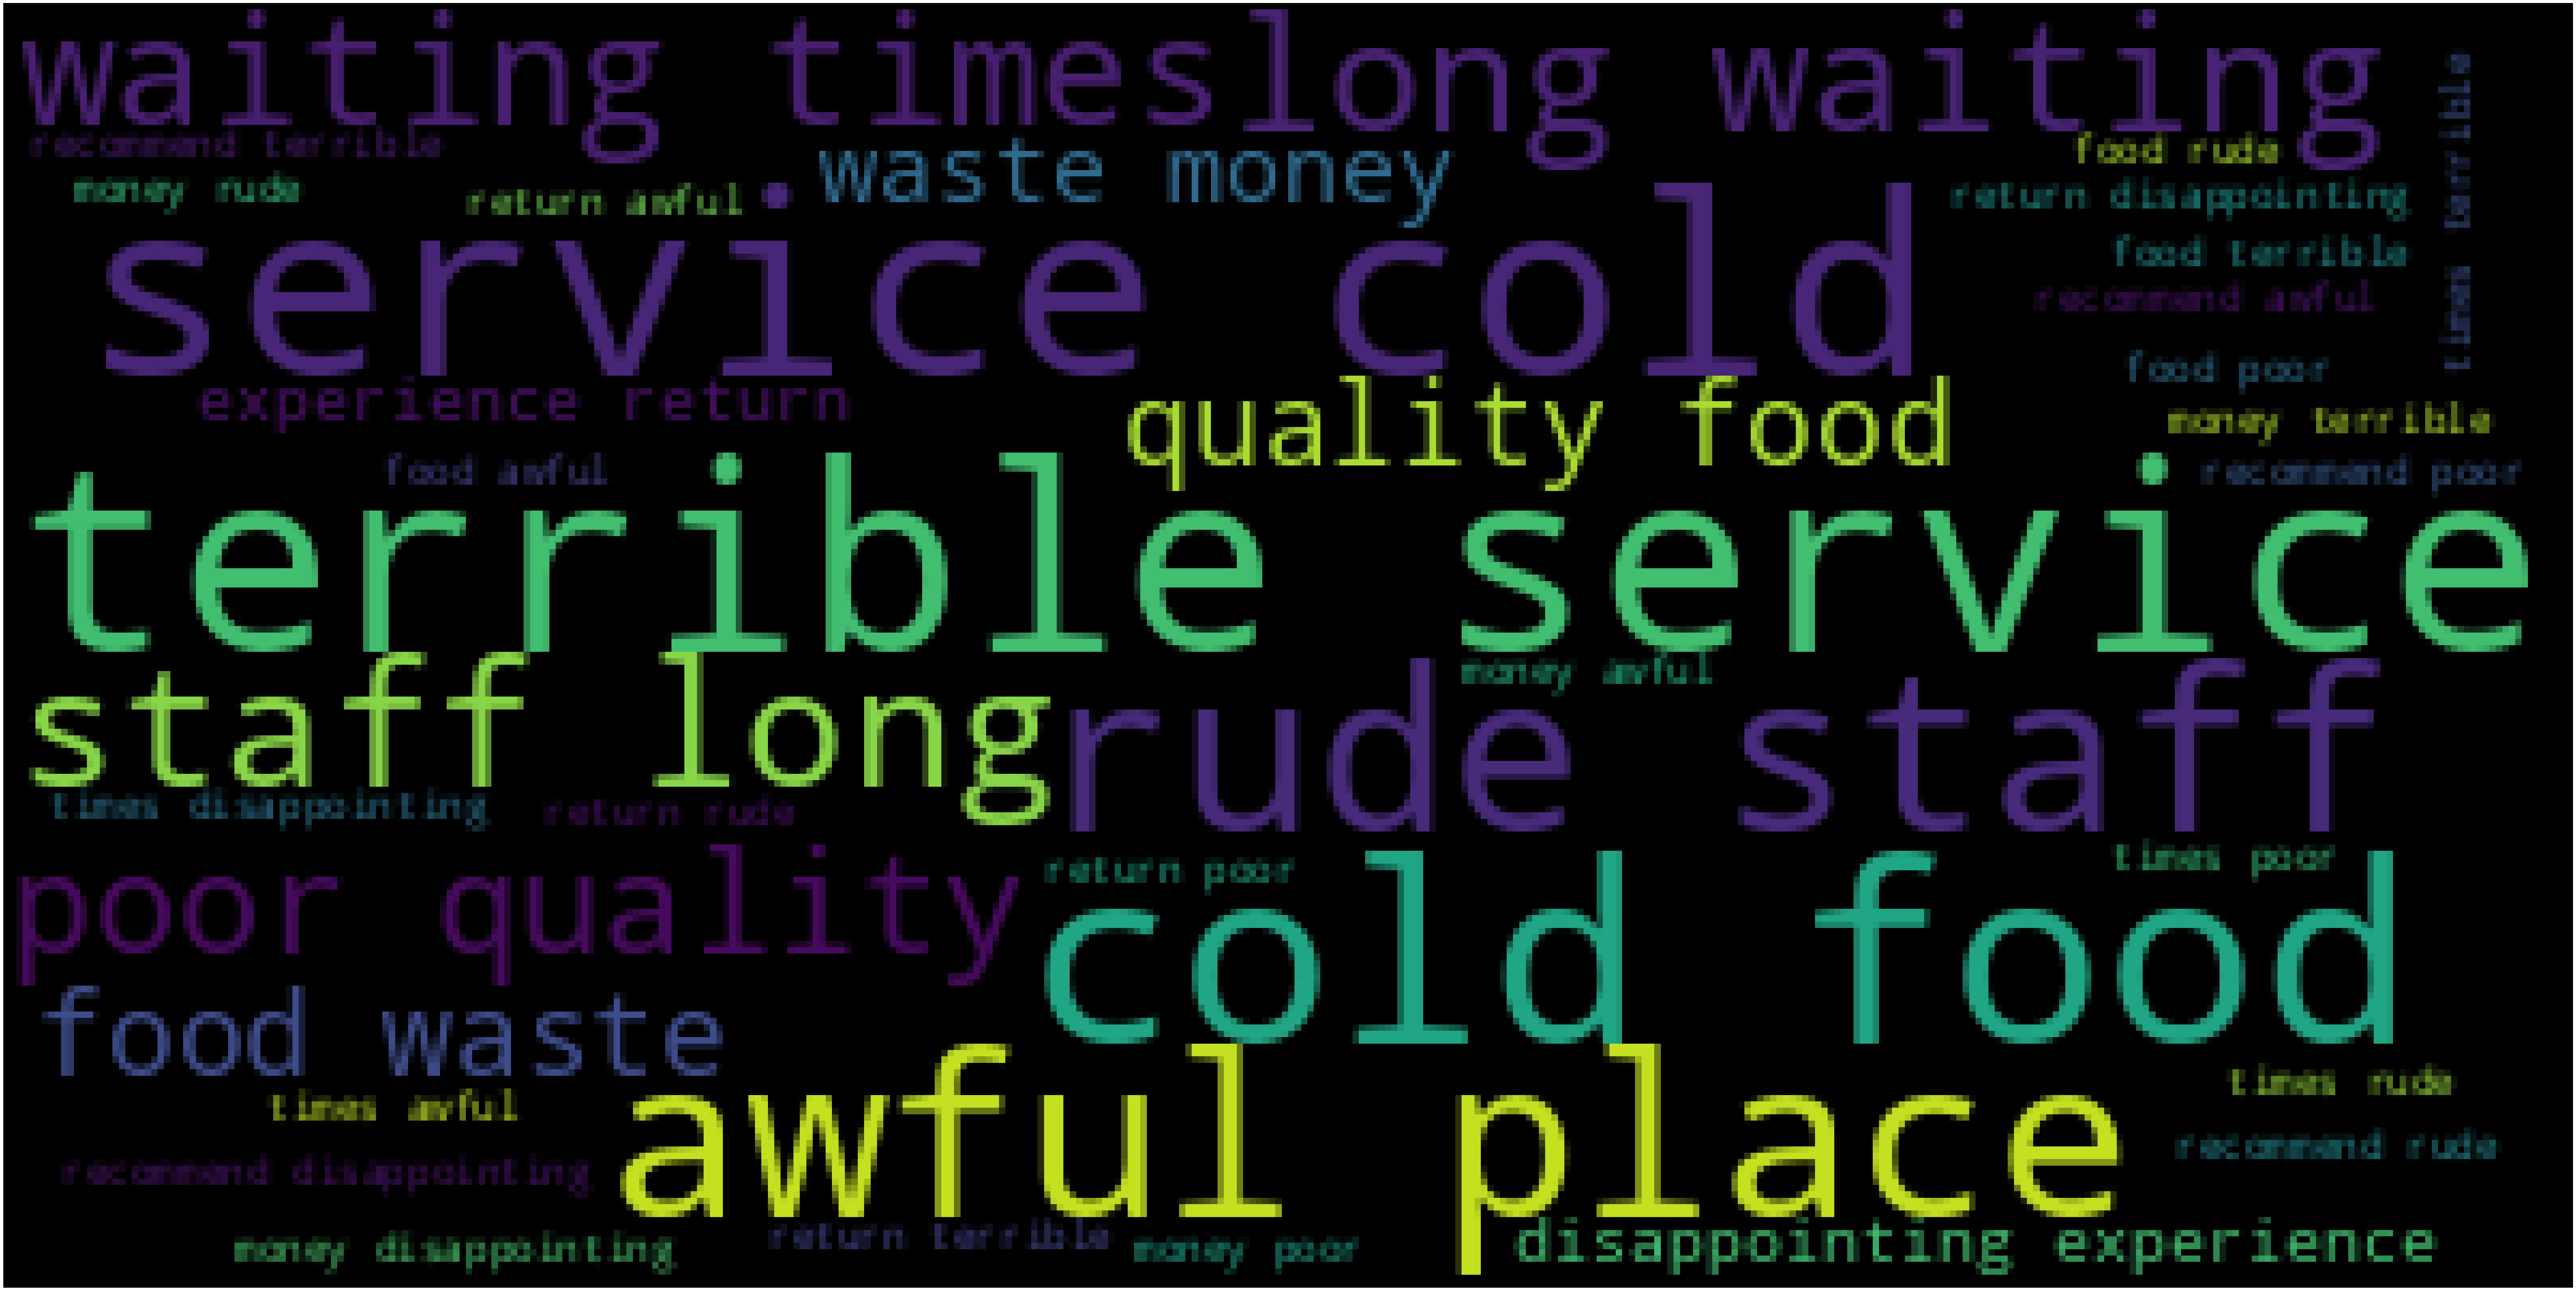

In [28]:
plot_word_frequency(cleaned_neg_trustpilot_tokens, 'Top 10 Most Frequent Words in negative trustpilot reviews', 10)
present_word_cloud(cleaned_neg_trustpilot_tokens)

# Initial topic modelling

In [29]:
df_neg_google_reviews.sample(3)

,Review Text,Review Stars,Restaurant Place,Creationdate,Review Language
1258,Good meal but a bit overpriced.,2,Birmingham Edgbaston,2023-04-05 02:53:37.218490,en
57,"Service was slow, but the food was decent.",2,Birmingham Edgbaston,2022-08-10 02:53:37.218490,en
2835,"Worst dining experience ever, avoid this place.",2,Liverpool City Centre,2023-10-11 02:53:37.218490,en


In [30]:
# Filter for the negative reviews that are from locations common to both data sets
df_filtered_neg_google_reviews = df_neg_google_reviews[df_neg_google_reviews['Restaurant Place'].isin(common_locations)]
df_filtered_neg_trustpilot_reviews = df_neg_trustpilot_reviews[df_neg_trustpilot_reviews['Location'].isin(common_locations)]

neg_google_reviews_as_list = df_filtered_neg_google_reviews['Review Text'].to_list()
neg_trustpilot_reviews_as_list = df_filtered_neg_trustpilot_reviews['Review Text'].to_list()

neg_reviews_common_loc = []
neg_reviews_common_loc.extend(neg_google_reviews_as_list)
neg_reviews_common_loc.extend(neg_trustpilot_reviews_as_list)

In [31]:
neg_reviews_common_loc[667]

'Rude staff and dirty tables, very disappointing.'

In [32]:
# Clean the list
neg_reviews_common_loc_tokens_clean, neg_reviews_common_loc_clean = preprocess(neg_reviews_common_loc)

In [33]:
# Use BERT topic
topic_model1 = BERTopic(verbose=True)
topics, probabilities = topic_model1.fit_transform(neg_reviews_common_loc_clean)

2026-06-03 08:49:01,797 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/326 [00:00<?, ?it/s]

2026-06-03 08:49:14,420 - BERTopic - Embedding - Completed ✓
2026-06-03 08:49:14,421 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 08:49:44,358 - BERTopic - Dimensionality - Completed ✓
2026-06-03 08:49:44,359 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 08:49:44,708 - BERTopic - Cluster - Completed ✓
2026-06-03 08:49:44,714 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 08:49:44,788 - BERTopic - Representation - Completed ✓


In [36]:
# Top 10 topics and document frequencies
topic_model1.get_topic_freq().head(10)

,Topic,Count
17,0,816
21,1,755
159,2,403
1,3,95
166,4,79
12,-1,79
64,5,71
49,6,68
40,7,62
87,8,62


In [37]:
# List words in top 2 topics
n = 2

for i in range(n):
  words = topic_model1.get_topic(i)
  print(f"\nTopic {i}:")
  for w_tuple in words:
    print(w_tuple[0])


Topic 0:
order
hour
wrong
waited







Topic 1:
tables
dirty
disappointing
rude
staff







Topic visualisation

In [38]:
# Present Intertopic Distance Map
topic_model1.visualize_topics()

In [39]:
# Show barchart of topics, showing top five words in each topic
topic_model1.visualize_barchart()

In [40]:
# Plot heatmap
topic_model1.visualize_heatmap()

Topic Analysis

In [41]:
topic_info1 = topic_model1.get_topic_info()
display(topic_info1[topic_info1['Topic'] != -1].head(10))

,Topic,Count,Name,Representation,Representative_Docs
1,0,816,0_order_hour_wrong_waited,"[order, hour, wrong, waited, , , , , , ]","[waited hour order wrong, waited hour order wr..."
2,1,755,1_tables_dirty_disappointing_rude,"[tables, dirty, disappointing, rude, staff, , ...","[rude staff dirty tables disappointing, rude s..."
3,2,403,2_return_disappointing_experience_,"[return, disappointing, experience, , , , , , , ]","[disappointing experience return, disappointin..."
4,3,95,3_okay_quite_dirty_place,"[okay, quite, dirty, place, food, , , , , ]","[food okay place quite dirty, food okay place ..."
5,4,79,4_times_waiting_long_rude,"[times, waiting, long, rude, staff, , , , , ]","[rude staff long waiting times, rude staff lon..."
6,5,71,5_washing_hands_witnessed_conditions,"[washing, hands, witnessed, conditions, unhygi...",[unhygienic conditions witnessed staff washing...
7,6,68,6_tasteless_absolutely_terrible_cold,"[tasteless, absolutely, terrible, cold, servic...",[absolutely terrible service food cold tastele...
8,7,62,7_ingredients_worth_money_poor,"[ingredients, worth, money, poor, quality, , ,...","[poor quality ingredients worth money, poor qu..."
9,8,62,8_tasteless_absolutely_terrible_cold,"[tasteless, absolutely, terrible, cold, servic...",[absolutely terrible service food cold tastele...
10,9,62,9_ingredients_worth_money_poor,"[ingredients, worth, money, poor, quality, , ,...","[poor quality ingredients worth money, poor qu..."


# Further data investigation

In [42]:
google_neg_reviews_by_loc = df_neg_google_reviews['Restaurant Place'].value_counts(ascending=False)

top_20_neg_google_reviews_by_loc = set(google_neg_reviews_by_loc.head(20).index)

print(
    "Top 20 locations for negative Google reviews:\n- " +
    "\n- ".join(sorted(top_20_neg_google_reviews_by_loc))
)

Top 20 locations for negative Google reviews:
- Birmingham City Centre
- Birmingham Edgbaston
- Birmingham Solihull
- Bristol Clifton
- Cardiff City Centre
- Edinburgh Old Town
- Glasgow City Centre
- Glasgow West End
- Leeds City Centre
- Leeds Headingley
- Liverpool City Centre
- London Camden
- London Canary Wharf
- London Chelsea
- London Hackney
- London Soho
- Manchester Central
- Manchester Didsbury
- Manchester Salford
- Sheffield Ecclesall Road


In [43]:
trustpilot_neg_reviews_by_loc = df_neg_trustpilot_reviews['Location'].value_counts(ascending=False)
top_20_neg_trustpilot_reviews_by_loc = set(trustpilot_neg_reviews_by_loc.head(20).index)

print(
    "Top 20 locations for negative Trustpilot reviews:\n- " +
    "\n- ".join(sorted([str(loc) for loc in top_20_neg_trustpilot_reviews_by_loc]))
)

Top 20 locations for negative Trustpilot reviews:
- Birmingham City Centre
- Birmingham Edgbaston
- Birmingham Solihull
- Bristol City Centre
- Cardiff Bay
- Cardiff City Centre
- Edinburgh New Town
- Glasgow City Centre
- Leeds City Centre
- Leeds Headingley
- Liverpool City Centre
- London Camden
- London Canary Wharf
- London Chelsea
- London Hackney
- London Soho
- Manchester Central
- Manchester Didsbury
- Manchester Salford
- Sheffield Ecclesall Road


In [44]:
# Identify common locations - 'are the locations roughly similar?'

common_loc = top_20_neg_google_reviews_by_loc & top_20_neg_trustpilot_reviews_by_loc
all_loc = top_20_neg_google_reviews_by_loc | top_20_neg_trustpilot_reviews_by_loc

print(f"The number of locations that feature in the top 20 negative reviews of both sets is: {len(common_loc)}")

The number of locations that feature in the top 20 negative reviews of both sets is: 17


In [45]:
common_loc

{'Birmingham City Centre',
 'Birmingham Edgbaston',
 'Birmingham Solihull',
 'Cardiff City Centre',
 'Glasgow City Centre',
 'Leeds City Centre',
 'Leeds Headingley',
 'Liverpool City Centre',
 'London Camden',
 'London Canary Wharf',
 'London Chelsea',
 'London Hackney',
 'London Soho',
 'Manchester Central',
 'Manchester Didsbury',
 'Manchester Salford',
 'Sheffield Ecclesall Road'}

**Plot the top 20 negative reviews in each channel by location**

In [46]:
geocoded_locations = {}

loc = Nominatim(
    user_agent="Geopy Library",
    timeout=20
)

for location in all_loc:
  try:
    getLoc = loc.geocode(str(location) + ", UK") # Add ', UK' to improve accuracy
    if getLoc:
      geocoded_locations[location] = {'latitude': getLoc.latitude, 'longitude': getLoc.longitude}
    else:
      geocoded_locations[location] = {'latitude': None, 'longitude': None}

  except Exception as e:
    print(f"Error geocoding {location}: {e}")
    geocoded_locations[location] = {'latitude': None, 'longitude': None}
    time.sleep(10)

Error geocoding London Chelsea: Non-successful status code 429
Error geocoding Sheffield Ecclesall Road: Non-successful status code 429
Error geocoding Glasgow West End: Non-successful status code 429


In [47]:
# Prepare data for plotting
plot_data = []

for location_name in top_20_neg_google_reviews_by_loc:
  if location in geocoded_locations and geocoded_locations[location_name]['latitude'] is not None and geocoded_locations[location_name]['longitude'] is not None :
    plot_data.append({
          'Location': location_name,
          'Latitude': geocoded_locations[location_name]['latitude'],
          'Longitude': geocoded_locations[location_name]['longitude'],
          'Source': 'Google Reviews'
        })

for location_name in top_20_neg_trustpilot_reviews_by_loc:
  if location in geocoded_locations and geocoded_locations[location_name]['latitude'] is not None and geocoded_locations[location_name]['longitude'] is not None :
    plot_data.append({
          'Location': location_name,
          'Latitude': geocoded_locations[location_name]['latitude'],
          'Longitude': geocoded_locations[location_name]['longitude'],
          'Source': 'Trustpilot Reviews'
        })

df_plot_locations = pd.DataFrame(plot_data)

In [48]:
import plotly.express as px

# Plot the locations on a map
fig = px.scatter_mapbox(
    df_plot_locations,
    lat="Latitude",
    lon="Longitude",
    color="Source",
    hover_name="Location",
    zoom=6,
    height=600,
    title="Locations of Top 20 Negative Reviews for each Source",
    size=[1.00000005]*len(df_plot_locations)
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

In [49]:
# Merge the two datasets and present results
df_google_neg_reviews_by_loc = pd.DataFrame()
df_google_neg_reviews_by_loc['Restaurant Place'] = google_neg_reviews_by_loc.index
df_google_neg_reviews_by_loc['Number of Negative Google Reviews'] = google_neg_reviews_by_loc.values
df_google_neg_reviews_by_loc.rename(columns={"Restaurant Place": "Location"}, inplace=True)

df_trustpilot_neg_reviews_by_loc = pd.DataFrame()
df_trustpilot_neg_reviews_by_loc['Location'] = trustpilot_neg_reviews_by_loc.index
df_trustpilot_neg_reviews_by_loc['Number of Negative trustpilot Reviews'] = trustpilot_neg_reviews_by_loc.values

df_all_neg_reviews_by_loc = pd.merge(df_google_neg_reviews_by_loc, df_trustpilot_neg_reviews_by_loc, on='Location', how='outer')
df_all_neg_reviews_by_loc['Number of Negative Google Reviews'] = df_all_neg_reviews_by_loc['Number of Negative Google Reviews'].fillna(0)
df_all_neg_reviews_by_loc['Number of Negative trustpilot Reviews'] = df_all_neg_reviews_by_loc['Number of Negative trustpilot Reviews'].fillna(0)
df_all_neg_reviews_by_loc['Total number of Negative Reviews'] = df_all_neg_reviews_by_loc['Number of Negative Google Reviews'] + df_all_neg_reviews_by_loc['Number of Negative trustpilot Reviews']

display(df_all_neg_reviews_by_loc.sort_values(by='Total number of Negative Reviews', ascending=False).head(30))

,Location,Number of Negative Google Reviews,Number of Negative trustpilot Reviews,Total number of Negative Reviews
17,London Chelsea,642,155,797
15,London Camden,591,158,749
16,London Canary Wharf,580,167,747
18,London Hackney,592,152,744
19,London Soho,585,127,712
0,Birmingham City Centre,438,100,538
20,Manchester Central,418,100,518
2,Birmingham Solihull,427,90,517
22,Manchester Salford,416,98,514
1,Birmingham Edgbaston,412,92,504


In [50]:
# Word frequencies for top 30 locations
top_30_locations = df_all_neg_reviews_by_loc.sort_values(by='Total number of Negative Reviews', ascending=False)['Location'].head(30).to_list()

filtered_neg_google_reviews = df_neg_google_reviews[df_neg_google_reviews['Restaurant Place'].isin(top_30_locations)]
filtered_neg_trustpilot_reviews = df_neg_trustpilot_reviews[df_neg_trustpilot_reviews['Location'].isin(top_30_locations)]

neg_google_reviews_as_list = filtered_neg_google_reviews['Review Text'].to_list()
neg_trustpilot_reviews_as_list = filtered_neg_trustpilot_reviews['Review Text'].to_list()

all_negative_reviews_top_30_locations = []
all_negative_reviews_top_30_locations.extend(neg_google_reviews_as_list)
all_negative_reviews_top_30_locations.extend(neg_trustpilot_reviews_as_list)

# Clean
all_negative_reviews_top_30_locations_tokens_clean, all_negative_reviews_top_30_locations_reviews_clean = preprocess(all_negative_reviews_top_30_locations)

In [51]:
top_30_locations

['London Chelsea',
 'London Camden',
 'London Canary Wharf',
 'London Hackney',
 'London Soho',
 'Birmingham City Centre',
 'Manchester Central',
 'Birmingham Solihull',
 'Manchester Salford',
 'Birmingham Edgbaston',
 'Manchester Didsbury',
 'Glasgow West End',
 'Bristol Clifton',
 'Edinburgh Old Town',
 'Sheffield Ecclesall Road',
 'Cardiff City Centre',
 'Glasgow City Centre',
 'Leeds City Centre',
 'Leeds Headingley',
 'Bristol City Centre',
 'Liverpool City Centre',
 'Cardiff Bay',
 'Liverpool Anfield',
 'Sheffield City Centre',
 'Edinburgh New Town']

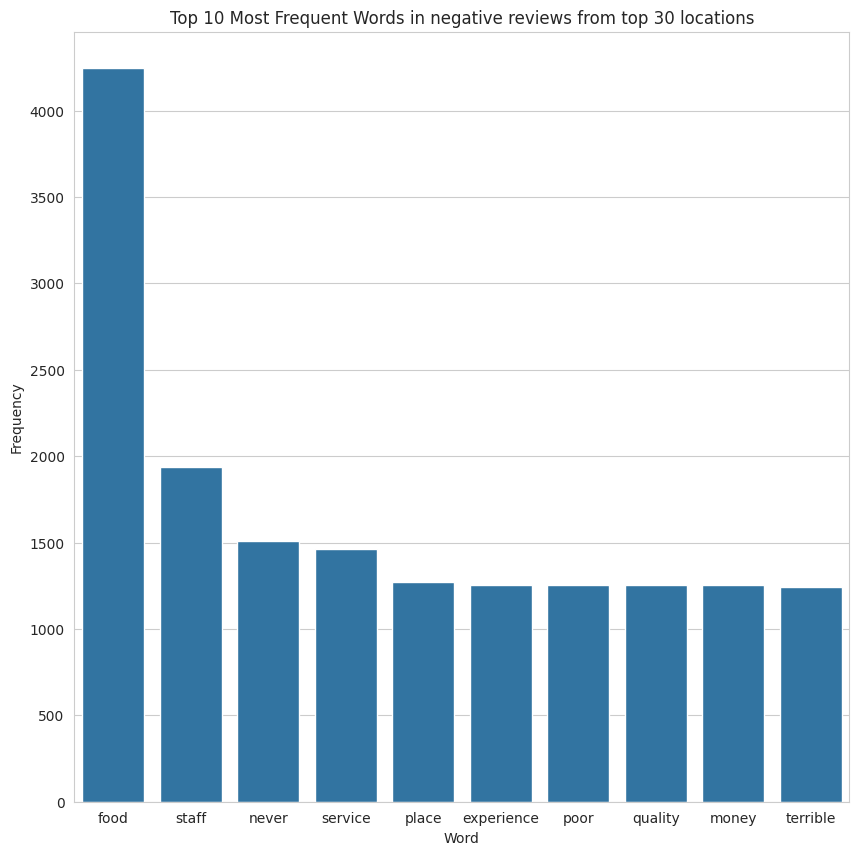

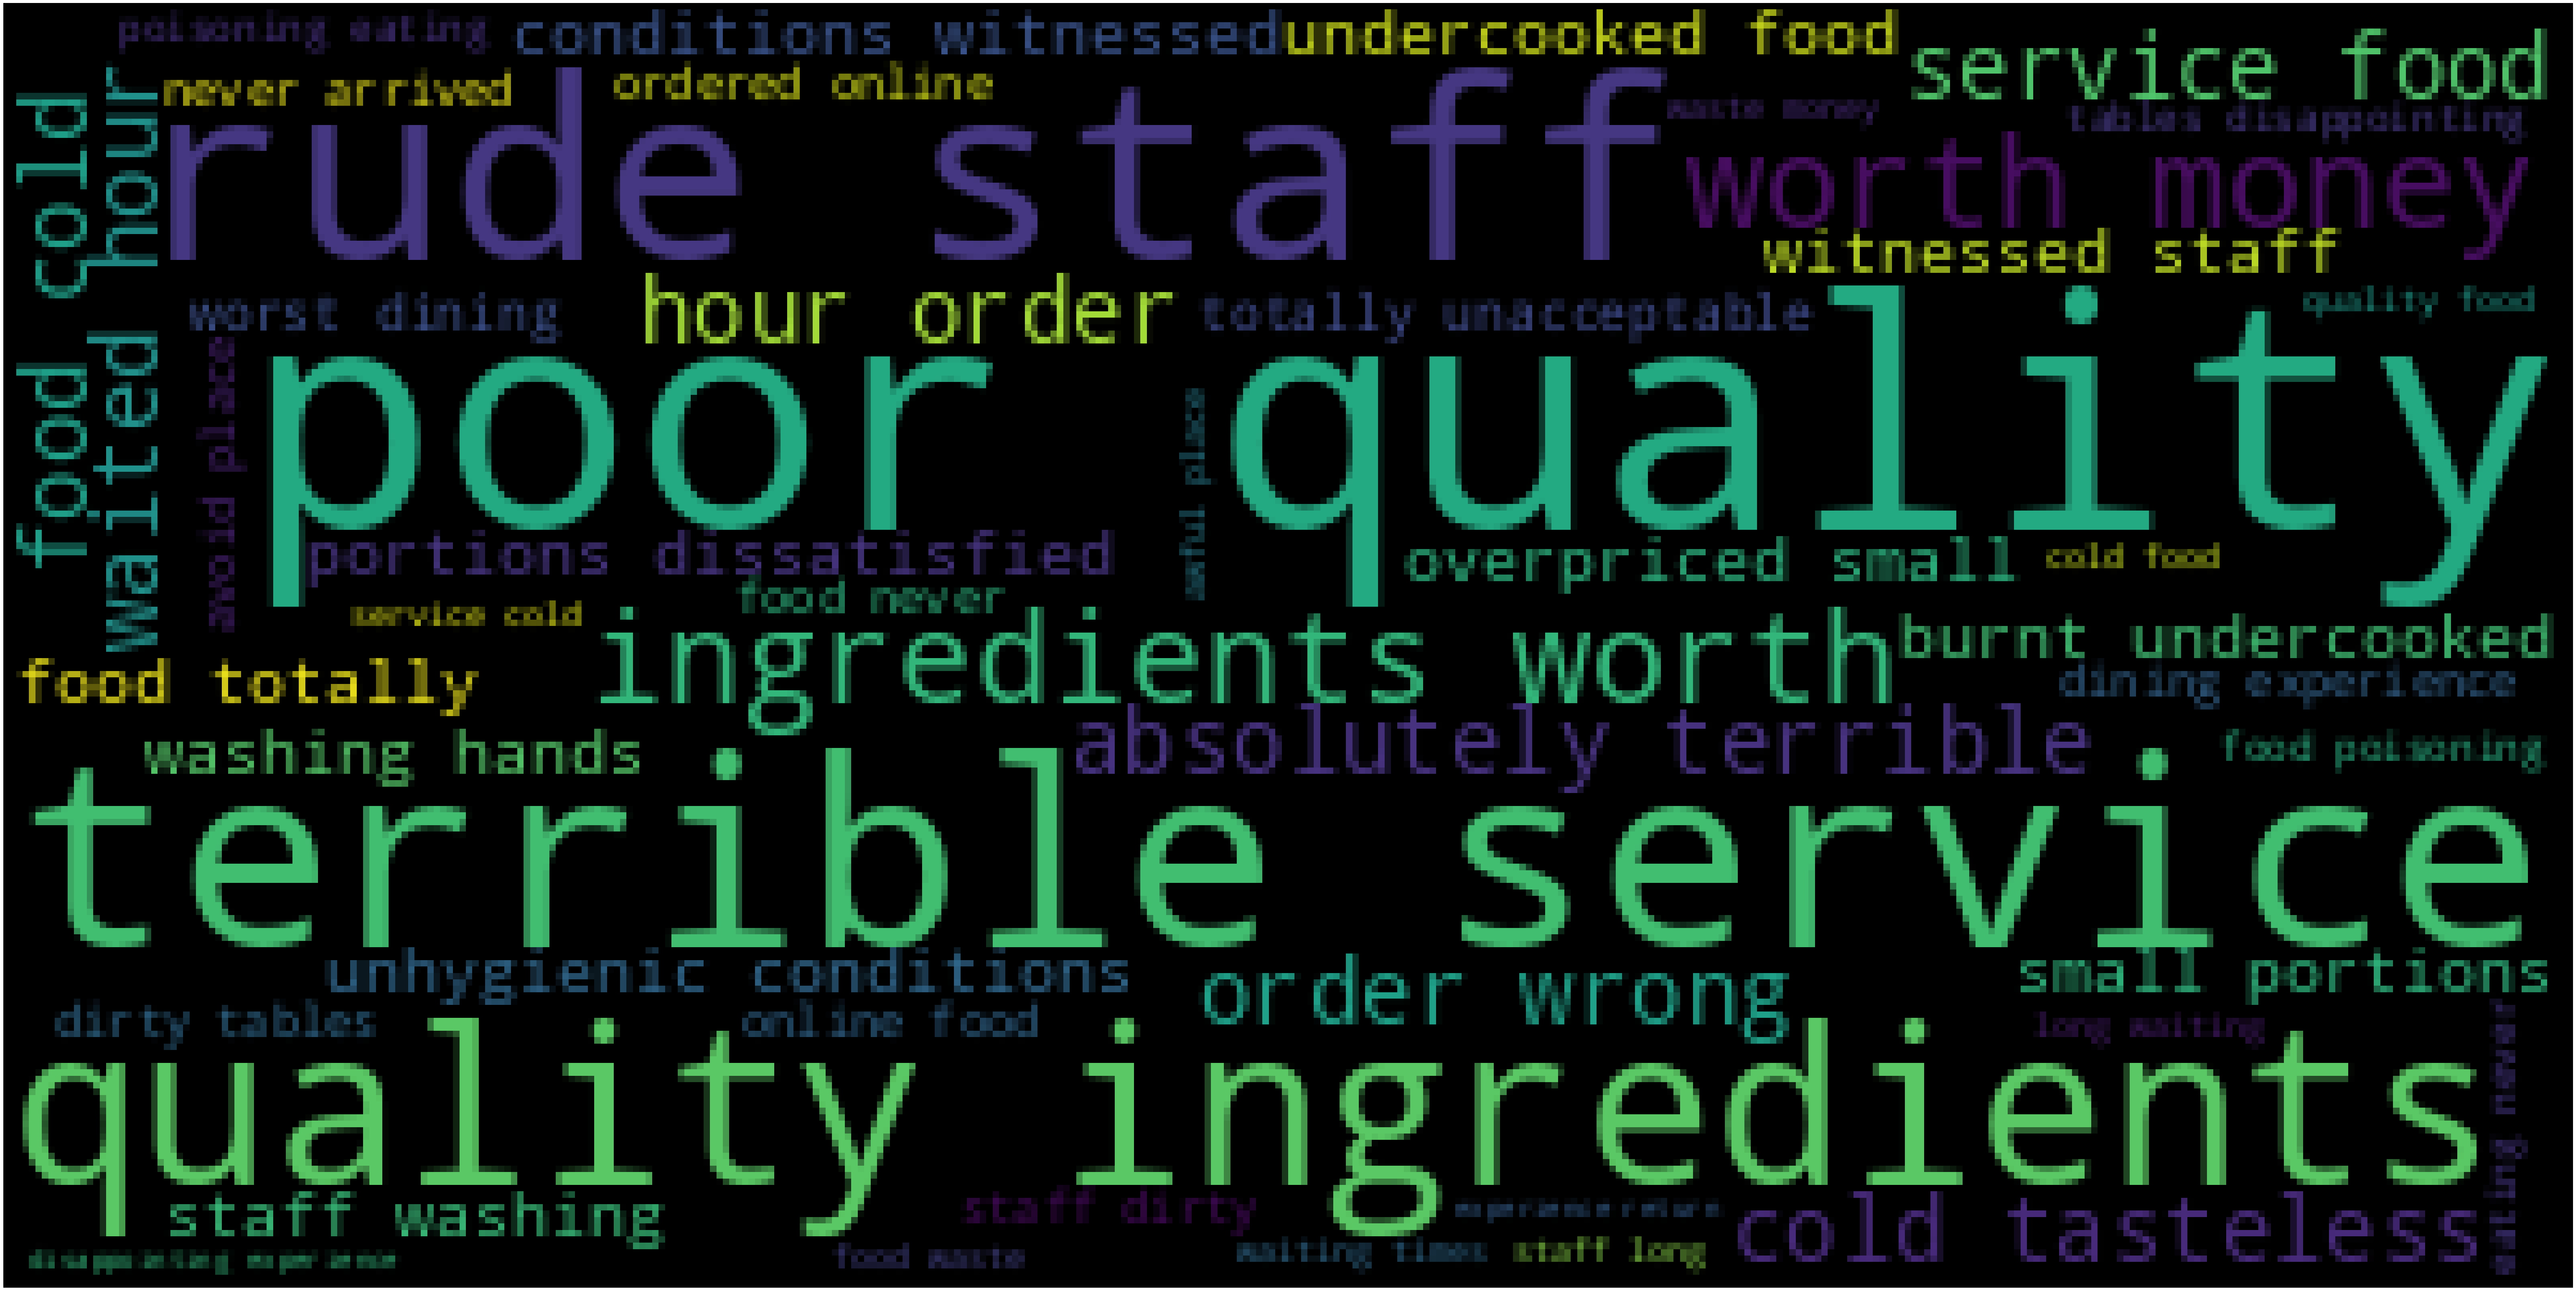

In [52]:
plot_word_frequency(all_negative_reviews_top_30_locations_tokens_clean, 'Top 10 Most Frequent Words in negative reviews from top 30 locations', 10)
present_word_cloud(all_negative_reviews_top_30_locations_tokens_clean)

In [53]:
all_negative_reviews_top_30_locations_reviews_clean[3]

'average experience nothing write home'

In [54]:
# Run through Bert topic
topic_model2 = BERTopic(verbose=True)
topics, probabilities = topic_model2.fit_transform(all_negative_reviews_top_30_locations_reviews_clean)

2026-06-03 08:51:43,649 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/326 [00:00<?, ?it/s]

2026-06-03 08:51:51,168 - BERTopic - Embedding - Completed ✓
2026-06-03 08:51:51,169 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 08:51:57,165 - BERTopic - Dimensionality - Completed ✓
2026-06-03 08:51:57,167 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 08:51:57,531 - BERTopic - Cluster - Completed ✓
2026-06-03 08:51:57,536 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 08:51:57,606 - BERTopic - Representation - Completed ✓


In [55]:
print('Topic frequencies for BERTopic model2:')
display(topic_model2.get_topic_freq())

Topic frequencies for BERTopic model2:


,Topic,Count
16,0,816
20,1,755
149,2,403
145,3,71
5,4,70
...,...,...
182,182,16
186,183,16
12,184,13
13,185,13


In [56]:
# Show barchart of topics, showing top five words in each topic
topic_model2.visualize_barchart()

In [57]:
topic_info2 = topic_model2.get_topic_info()
display(topic_info2[topic_info2['Topic'] != -1].head(10))

,Topic,Count,Name,Representation,Representative_Docs
1,0,816,0_order_hour_wrong_waited,"[order, hour, wrong, waited, , , , , , ]","[waited hour order wrong, waited hour order wr..."
2,1,755,1_tables_dirty_disappointing_rude,"[tables, dirty, disappointing, rude, staff, , ...","[rude staff dirty tables disappointing, rude s..."
3,2,403,2_return_disappointing_experience_,"[return, disappointing, experience, , , , , , , ]","[disappointing experience return, disappointin..."
4,3,71,3_terrible_cold_service_food,"[terrible, cold, service, food, , , , , , ]","[terrible service cold food, terrible service ..."
5,4,70,4_bit_meal_good_overpriced,"[bit, meal, good, overpriced, , , , , , ]","[good meal bit overpriced, good meal bit overp..."
6,5,67,5_ingredients_worth_money_poor,"[ingredients, worth, money, poor, quality, , ,...","[poor quality ingredients worth money, poor qu..."
7,6,67,6_ingredients_worth_money_poor,"[ingredients, worth, money, poor, quality, , ,...","[poor quality ingredients worth money, poor qu..."
8,7,67,7_dissatisfied_small_portions_overpriced,"[dissatisfied, small, portions, overpriced, , ...","[overpriced small portions dissatisfied, overp..."
9,8,66,8_ingredients_worth_money_poor,"[ingredients, worth, money, poor, quality, , ,...","[poor quality ingredients worth money, poor qu..."
10,9,66,9_terrible_cold_service_food,"[terrible, cold, service, food, , , , , , ]","[terrible service cold food, terrible service ..."


# Emotion Analysis

In [58]:
tokenizer = AutoTokenizer.from_pretrained("bhadresh-savani/bert-base-uncased-emotion")

emotion_model = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion"
)

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [61]:
# Test
neg_emotion = 'I am livid at the state of the food that I was given: I think I might simply explode with rage'
emotion_model(neg_emotion)

[{'label': 'anger', 'score': 0.8839807510375977}]

In [62]:
# Test
pos_emotion = 'I adore the restuarant food; it is blissful like ambrosia for the Greek Gods in Mount Olympus'
emotion_model(pos_emotion)

[{'label': 'joy', 'score': 0.9968618154525757}]

In [63]:
# Create chunking function as BERT has an upper limit of 512 tokens
def chunk_text(text, max_tokens=510):
  input_ids = tokenizer(text, add_special_tokens=False)["input_ids"]

  chunks = []
  for i in range(0, len(input_ids), max_tokens):
    chunk_ids = input_ids[i:i+max_tokens]
    chunk_text = tokenizer.decode(chunk_ids)
    chunks.append(chunk_text)

  return chunks

In [64]:
# Function to identify emotions in a batch
def classify_batch(batch):
  results = []

  for text in batch['Review Text']:

    chunks = chunk_text(text)

    # Run model - will return emotions for the chunks in one review
    outputs = emotion_model(chunks, batch_size=16)

    best_label = None
    best_score = -1

    for chunk_output in outputs:
      score = chunk_output["score"]
      label = chunk_output["label"]

      if score > best_score:
        best_score = score
        best_label = label

    # store result
    results.append(best_label)

  return {"emotion": results}

In [65]:
# For efficiency, convert from pandas dataframe to Hugging Face dataset

hf_google = Dataset.from_pandas(google)
hf_trustpilot = Dataset.from_pandas(trustpilot)

In [66]:
hf_google = hf_google.map(
     classify_batch,
     batched=True,
     batch_size=32
 )

Map:   0%|          | 0/21338 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [67]:
df_google_with_emotions = hf_google.to_pandas()
df_google_with_emotions.sample(3)

,Review Text,Review Stars,Restaurant Place,Creationdate,Review Language,__index_level_0__,emotion
15794,"Absolutely terrible service, food was cold and...",1,Sheffield Ecclesall Road,2024-05-04 02:53:37.218490,en,15907,anger
15124,"Absolutely terrible service, food was cold and...",1,Edinburgh New Town,2024-04-24 02:53:37.218490,en,15229,anger
9534,"Rude staff and dirty tables, very disappointing.",1,Manchester Salford,2024-01-27 02:53:37.218490,en,9596,anger


In [68]:
hf_trustpilot = hf_trustpilot.map(
     classify_batch,
     batched=True,
     batch_size=32
 )

Map:   0%|          | 0/10237 [00:00<?, ? examples/s]

In [70]:
df_trustpilot_with_emotions = hf_trustpilot.to_pandas()
df_trustpilot_with_emotions.sample(3)

,Review Text,Review Stars,Location,DateTime,Review Language,__index_level_0__,emotion
2948,Fantastic food and great service!,4,London Soho,2024-02-01 02:24:00.048415,en,2982,joy
1472,"Loved the burgers here, will definitely come b...",4,Birmingham Solihull,2023-10-30 02:24:00.048415,en,1489,love
3410,Rude staff and long waiting times.,1,London Soho,2024-03-04 02:24:00.048415,en,3450,anger


Visualise the emotion distribution across negative reviews



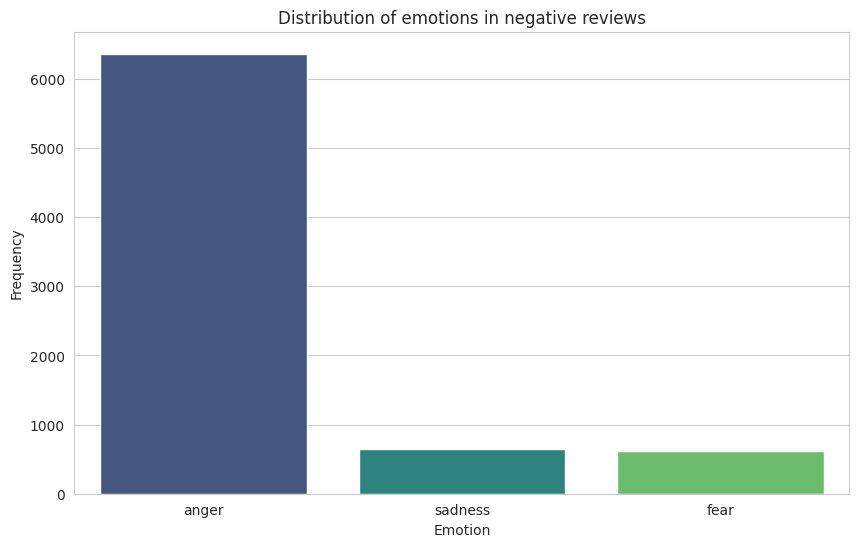

In [71]:
emotions_in_neg_reviews = df_google_with_emotions[df_google_with_emotions['Review Stars'] < 2]['emotion'].to_list()
emotions_in_neg_reviews.extend(df_trustpilot_with_emotions[df_trustpilot_with_emotions['Review Stars'] < 2]['emotion'].to_list())

emotion_counts = pd.Series(emotions_in_neg_reviews).value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.title("Distribution of emotions in negative reviews")
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.show()

In [72]:
emotion_counts

,count
anger,6362
sadness,652
fear,617


Carry out topic analysis on reviews where anger is the dominant emotion

In [73]:
neg_reviews_anger = df_google_with_emotions[df_google_with_emotions['emotion'] == 'anger']['Review Text'].to_list()
neg_reviews_anger.extend(df_trustpilot_with_emotions[df_trustpilot_with_emotions['emotion'] == 'anger']['Review Text'].to_list())

_, neg_reviews_anger_clean = preprocess(neg_reviews_anger)

In [74]:
# Run through Bert topic
topic_model3 = BERTopic(verbose=True)
topics, probabilities = topic_model3.fit_transform(neg_reviews_anger_clean)

2026-06-03 08:58:13,694 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/248 [00:00<?, ?it/s]

2026-06-03 08:58:20,822 - BERTopic - Embedding - Completed ✓
2026-06-03 08:58:20,823 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 08:58:30,831 - BERTopic - Dimensionality - Completed ✓
2026-06-03 08:58:30,832 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 08:58:31,103 - BERTopic - Cluster - Completed ✓
2026-06-03 08:58:31,107 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 08:58:31,164 - BERTopic - Representation - Completed ✓


In [75]:
# Present Intertopic Distance Map
topic_model3.visualize_topics()

In [76]:
# Show barchart of topics, showing top five words in each topic
topic_model3.visualize_barchart()

In [77]:
topic_info3 = topic_model3.get_topic_info()
display(topic_info3[topic_info3['Topic'] != -1].head(10))

,Topic,Count,Name,Representation,Representative_Docs
1,0,816,0_order_hour_wrong_waited,"[order, hour, wrong, waited, , , , , , ]","[waited hour order wrong, waited hour order wr..."
2,1,755,1_tables_disappointing_dirty_rude,"[tables, disappointing, dirty, rude, staff, , ...","[rude staff dirty tables disappointing, rude s..."
3,2,69,2_tasteless_absolutely_service_cold,"[tasteless, absolutely, service, cold, terribl...",[absolutely terrible service food cold tastele...
4,3,67,3_washing_hands_witnessed_conditions,"[washing, hands, witnessed, conditions, unhygi...",[unhygienic conditions witnessed staff washing...
5,4,66,4_poor_ingredients_worth_quality,"[poor, ingredients, worth, quality, money, , ,...","[poor quality ingredients worth money, poor qu..."
6,5,65,5_washing_hands_witnessed_conditions,"[washing, hands, witnessed, conditions, unhygi...",[unhygienic conditions witnessed staff washing...
7,6,63,6_overpriced_dissatisfied_small_portions,"[overpriced, dissatisfied, small, portions, , ...","[overpriced small portions dissatisfied, overp..."
8,7,62,7_dining_avoid_place_worst,"[dining, avoid, place, worst, experience, ever...","[worst dining experience ever avoid place, wor..."
9,8,62,8_poor_ingredients_worth_quality,"[poor, ingredients, worth, quality, money, , ,...","[poor quality ingredients worth money, poor qu..."
10,9,61,9_poor_ingredients_worth_quality,"[poor, ingredients, worth, quality, money, , ,...","[poor quality ingredients worth money, poor qu..."


# Use a Large Language Model - in this instance, Ollama

In [93]:
!pip install ollama

In [94]:
import ollama
from ollama import Client

Set-up Ollama

In [ ]:
# Install dependencies
!sudo apt-get update
!sudo apt-get install -y zstd pciutils
!curl -fsSL https://ollama.ai/install.sh | sh

# Setup NVIDIA drivers
!echo 'debconf debconf/frontend select Noninteractive' | sudo debconf-set-selections
!sudo apt-get install -y cuda-drivers
import os
os.environ.update({'LD_LIBRARY_PATH': '/usr/lib64-nvidia'})

In [96]:
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [97]:
!ollama pull phi4-mini

In [98]:
!ollama list

NAME                ID              SIZE      MODIFIED               
phi4-mini:latest    78fad5d182a7    2.5 GB    Less than a second ago    


In [99]:
client = Client(host="http://localhost:11434", timeout=600)

In [100]:
# Create a list of all negative reviews

all_neg_reviews = df_neg_google_reviews['Review Text'].to_list()
all_neg_reviews.extend(df_neg_trustpilot_reviews['Review Text'].to_list())

all_neg_reviews[67]

'Service was slow, but the food was decent.'

In [101]:
len(all_neg_reviews)

10411

In [102]:
def run_llm_chat(messages, model, temperature):

  response = client.chat(
        messages=messages,
        model=model,
        options={"temperature": temperature, "num_ctx": 2192, "num_predict": 1000})

  return response.message.content

In [ ]:
all_extracted_topics = []
save_path = 'all_extracted_topicsV2.pkl'

# Try to load previously saved topics
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        all_extracted_topics = pickle.load(f)
    print(f"Resuming from {len(all_extracted_topics)} previously extracted topics.")

start_index = len(all_extracted_topics)

for i, review in enumerate(all_neg_reviews):
  if i < start_index: # Skip reviews already processed
    continue

  if len(str(review)) < 1000:
    message = [
        {
          "role": "system",
          "content": (
            "You extract topics from customer reviews. "
          )
        },
        {
            "role": "user",
            "content": (
                f"In the following customer review, pick out the main 3 topics. Return them in a numbered list format, with each one on a new line."
                f"{review}"
            )
        }
    ]

    try:
        output = run_llm_chat(message, model="phi4-mini", temperature=0.2)
        all_extracted_topics.append(output)

        # Save checkpoint every 100 reviews
        if (i + 1) % 100 == 0:
            with open(save_path, 'wb') as f:
                pickle.dump(all_extracted_topics, f)
            print(f"Checkpoint saved after processing {i + 1} reviews.")

    except Exception as e:
        print(f"Error processing review {i}: {e}. Saving current progress.")
        with open(save_path, 'wb') as f:
            pickle.dump(all_extracted_topics, f)
        break # Stop processing on error

# Final save after loop completion
with open(save_path, 'wb') as f:
    pickle.dump(all_extracted_topics, f)
print(f"Finished processing. Total topics extracted: {len(all_extracted_topics)}.")

In [105]:
# Create a comprehensive list of all LLM identified topics from negative reviews
llm_topics_list = []

if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        all_extracted_topics = pickle.load(f)
else:
  print("Unable to access llm extracted topics")

for topic_set in all_extracted_topics:
  # Split the string by newlines to get individual topics
  individual_topics = topic_set.strip().split('\n')
  for topic in individual_topics:
    # Remove the leading number, dot, and space (e.g., '1. ')
    cleaned_topic = re.sub(r'^\d+\.\s*', '', topic.strip())
    if cleaned_topic:  # Ensure the topic is not empty after cleaning
      llm_topics_list.append(cleaned_topic)

In [106]:
llm_topics_list[67]

'Food quality'

In [107]:
_, llm_topics_list_clean = preprocess(llm_topics_list)

In [108]:
llm_topics_list_clean[67]

'food quality'

In [109]:
# Run through Bert topic
topic_model4 = BERTopic(verbose=True)
topics, probabilities = topic_model4.fit_transform(llm_topics_list_clean)

2026-06-03 11:15:26,722 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/977 [00:00<?, ?it/s]

2026-06-03 11:15:38,926 - BERTopic - Embedding - Completed ✓
2026-06-03 11:15:38,927 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 11:15:55,808 - BERTopic - Dimensionality - Completed ✓
2026-06-03 11:15:55,809 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 11:15:58,476 - BERTopic - Cluster - Completed ✓
2026-06-03 11:15:58,489 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 11:15:58,651 - BERTopic - Representation - Completed ✓


In [110]:
topic_model4.visualize_topics()

In [111]:
topic_model4.visualize_barchart()

In [112]:
topic_info4 = topic_model4.get_topic_info()
display(topic_info4[topic_info4['Topic'] != -1].head(10))

,Topic,Count,Name,Representation,Representative_Docs
1,0,839,0_worth_money_visiting_,"[worth, money, visiting, , , , , , , ]","[worth money, worth money, worth money]"
2,1,789,1_product_dissatisfaction_quality_,"[product, dissatisfaction, quality, , , , , , , ]","[dissatisfaction product quality, dissatisfact..."
3,2,233,2_temperature_food__,"[temperature, food, , , , , , , , ]","[food temperature, food temperature, food temp..."
4,3,167,3_satisfaction_overall__,"[satisfaction, overall, , , , , , , , ]","[overall satisfaction, overall satisfaction, o..."
5,4,136,4_dining_overall_experience_restaurant,"[dining, overall, experience, restaurant, , , ...","[overall dining experience, overall dining exp..."
6,5,131,5_overall_experience__,"[overall, experience, , , , , , , , ]","[overall experience, overall experience, overa..."
7,6,125,6_temperature_food__,"[temperature, food, , , , , , , , ]","[temperature food, temperature food, temperatu..."
8,7,99,7_product_dissatisfaction_service_,"[product, dissatisfaction, service, , , , , , , ]","[dissatisfaction product service, dissatisfact..."
9,8,99,8_taste_tasteless_food_meal,"[taste, tasteless, food, meal, , , , , , ]","[taste food, taste food, taste food]"
10,9,97,9_control_temperature__,"[control, temperature, , , , , , , , ]","[temperature control, temperature control, tem..."


In [ ]:
display(topic_info4[topic_info4['Topic'] == -1].head(10))

In [ ]:
# Identify actionable insights from the negative reviews
message2 = [
        {
          "role": "system",
          "content": (
            "You are a senior business analyist advising a gym company on how they can improve the customer experience by identifying actionable insights within their customer reviews, alongside suggestions on how to effectively address them."
          )
        },
        {
            "role": "user",
            "content": (
                f"For the following text topics obtained from negative customer reviews, can you give some actionable insights that would help this gym company?"
                f"{llm_topics_list}"
            )
        }
    ]

output = run_llm_chat(messages=message2, model="phi4-mini", temperature=0.2)

# Using Gensim

In [ ]:
!pip install gensim nltk datasets pyLDAvis ipykernel

**Perform the preprocessing required to run the LDA model from Gensim. Use the list of negative reviews (combined Google and Trustpilot reviews).**

In [ ]:
# Create a dictionary representation of the text.
from gensim import corpora
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemma = WordNetLemmatizer()

all_cleaned_review_strings = cleaned_neg_google_reviews + cleaned_neg_trustpilot_reviews

normalized = []

for review_string in all_cleaned_review_strings:
  # Tokenize the already cleaned review string
    tokens = word_tokenize(review_string)
    # Lemmatize each token
    lemmatized_tokens = [lemma.lemmatize(token) for token in tokens]
    normalized.append(lemmatized_tokens)

In [ ]:
normalized[67]

['busy',
 'smell',
 'genuinely',
 'awful',
 'bad',
 'ventilation',
 'positive',
 'load',
 'parking',
 'back']

In [ ]:
dictionary = corpora.Dictionary(normalized)

# Filter out words that occur in fewer than 2 documents or more than 50% of the documents.
dictionary.filter_extremes(no_below=2, no_above=0.5)

In [ ]:
# Set parameters.
num_topics = 10
passes = 20

# Create the bag-of-words corpus.
corpus = [dictionary.doc2bow(doc) for doc in normalized]

# Create the LDA model.
from gensim.models.ldamodel import LdaModel
lda_model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=passes)

In [ ]:
# Visualise the topics
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Prepare the visualisation.
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)